In [1]:
import sys, pathlib
BEDL = pathlib.Path("/project/6004619/dcs01/PyLDL/bedl_experiments")
if str(BEDL) not in sys.path:
    sys.path.insert(0, str(BEDL))

In [2]:

import importlib
import helpers

importlib.reload(helpers)
from helpers import read_results, dataframe_to_latex_table
import pandas as pd
import numpy as np

E0000 00:00:1779480019.346884  885566 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779480019.892176  885566 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779480022.339419  885566 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779480022.339455  885566 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779480022.339458  885566 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779480022.339460  885566 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
def combine_folds(model, dataset, metrics):
    
    records = []
    for fold in list(range(10)):
        results = read_results(model, dataset, fold)
        record = {
            'model': model,
            'dataset': dataset,
            'fold': fold
        }
        full_metrics = []
        for metric in metrics:
            if type(results.get(f'{metric}_mean')) is list:
                record_list = results[f'{metric}_mean']
                for i, value in enumerate(record_list):
                    record[f'{metric}_{i}_mean'] = value
                    record[f'{metric}_{i}_var'] = results[f'{metric}_var'][i]
                    full_metrics.append(f'{metric}_{i}')

            else:
                record[f'{metric}_mean'] = results[f'{metric}_mean']
                record[f'{metric}_var'] = results[f'{metric}_var']
                record[f'{metric}_std'] = results[f'{metric}_var']**0.5
                full_metrics.append(metric)
        records.append(record)

    all_metrics_df = pd.DataFrame.from_records(records)
    combined = {
        'model': model,
        'dataset': dataset,
    }
    for metric in full_metrics:
        combined[f'{metric}_mean'] = all_metrics_df[f'{metric}_mean'].mean()
        combined[f'{metric}_err'] = all_metrics_df[f'{metric}_mean'].std() / (10 ** 0.5)
        metric_var = all_metrics_df[f'{metric}_var'].mean() + all_metrics_df[f'{metric}_mean'].var(ddof=0)
        combined[f'{metric}_std'] = metric_var**0.5
    
    return combined

def combine_metrics(models, datasets,
                    metrics, compact=False):

    all_results = []
    for model in models:
        for dataset in datasets:
            fold_results = combine_folds(model, dataset, metrics)
            all_results.append(fold_results)

    df = pd.DataFrame.from_records(all_results)
    df.sort_values(metrics[0] + '_mean', inplace=True)
    if compact:
        df = compact_metrics(df)
    return df

def compact_metrics(df):
    compacted = []
    for _, row in df.iterrows():
        record = {
            'model': row['model'],
            'dataset': row['dataset']
        }
        for col in df.columns:
            if col not in ['model', 'dataset']:
                if col.endswith('_mean'):
                    metric_name = col.replace('_mean', '')
                    err_col = f'{metric_name}_err'
                    if err_col in df.columns:
                        record[metric_name] = f"{row[col]:.3f}±{row[err_col]:.3f}"
                    else:
                        record[metric_name] = f"{row[col]:.3f}"
                elif not col.endswith('_err') and not col.endswith('_std'):
                    record[col] = row[col]
        compacted.append(record)
    return pd.DataFrame.from_records(compacted)


In [4]:
def _to_float(v):
    """Parse a compact 'mean±err' cell (or a plain number) to float."""
    return float(str(v).split('±')[0])

def plot_marginal_coverage(df, prefix, ax, title):
    # ordered per-level columns: <prefix>_0 ... <prefix>_M
    cols = [c for c in df.columns
            if c.startswith(prefix + '_') and c.rsplit('_', 1)[1].isdigit()]
    cols.sort(key=lambda c: int(c.rsplit('_', 1)[1]))
    x = np.linspace(0., 1., len(cols))          # matches default mc_levels grid

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect')
    for _, row in df.iterrows():
        y = [_to_float(row[c]) for c in cols]
        ax.plot(x, y, marker='o', ms=3, label=row['model'])

    ax.set_xlabel('Expected coverage')
    ax.set_ylabel('Observed coverage')
    ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.legend(fontsize=7)


def plot_conformal_residuals(models, dataset, ax, n_folds=10):
    name_map = {"BEDL": "BDL", "AA_BP": "DP", "SNEFY_LDL": "SNEFY"}

    for model in models:
        first_res = read_results(model, dataset, 0)
        x = np.asarray(first_res["mc_levels"], dtype=float)

        fold_curves = [
            np.asarray(first_res["marginal_coverage_cal_mean"], dtype=float) - x
        ]
        for fold in range(1, n_folds):
            res = read_results(model, dataset, fold)
            yc = np.asarray(res["marginal_coverage_cal_mean"], dtype=float)
            fold_curves.append(yc - x)

        mean_residual = np.mean(np.vstack(fold_curves), axis=0)
        ax.plot(x, mean_residual, marker="o", ms=3, label=name_map.get(model, model))

    ax.axhline(0.0, color="k", linestyle="--", linewidth=1, label="one-to-one line (residual=0)")
    ax.set_xlabel("Expected coverage")
    ax.set_ylabel("Residual")
    ax.set_title(f"Coverage residuals (conformal recalibration)")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

In [5]:
from typing import Optional

def dataframe_to_latex_table(
    df: pd.DataFrame,
    output_file: str,
    caption: str = "Table",
    label: str = "tab:data",
    bold_header: bool = True,
    monospace_first_col: bool = True,
    include_index: bool = False,
    column_alignment: Optional[str] = None,
    escape_special_chars: bool = True,
    round_float: int = 4,
) -> None:
    """
    Convert a pandas DataFrame to a LaTeX table and save to a text file.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to convert
    output_file : str
        Path to save the LaTeX table (e.g., 'table.txt')
    caption : str, default "Table"
        Table caption
    label : str, default "tab:data"
        LaTeX label for referencing the table
    bold_header : bool, default True
        Whether to bold the header row
    monospace_first_col : bool, default True
        Whether to format first column as monospace (texttt)
    include_index : bool, default False
        Whether to include the DataFrame index as first column
    column_alignment : str, optional
        Column alignment string (e.g., 'lccc'). If None, auto-generates based on content
    escape_special_chars : bool, default True
        Whether to escape LaTeX special characters
    
    Returns
    -------
    None
        Saves the LaTeX code to output_file
    
    Examples
    --------
    >>> df = pd.DataFrame({
    ...     'Model': ['Model A', 'Model B'],
    ...     'Metric1': [0.85, 0.90],
    ...     'Metric2': [0.92, 0.88]
    ... })
    >>> dataframe_to_latex_table(df, 'my_table.txt', 
    ...                          caption='Model Performance',
    ...                          label='tab:performance')
    """
    
    # Create a copy to avoid modifying original
    df_copy = df.copy()
    
    if not include_index:
        df_copy = df_copy.reset_index(drop=True)
    
    # Number of columns
    num_cols = len(df_copy.columns)
    
    # Auto-generate column alignment if not provided
    if column_alignment is None:
        # First column left-aligned, rest center-aligned
        column_alignment = 'l' + 'c' * (num_cols - 1)
    
    # Escape special LaTeX characters
    def escape_latex(text):
        if not escape_special_chars:
            return str(text)
        text = str(text)
        text = text.replace('\\', r'\textbackslash{}')
        text = text.replace('_', r'\_')
        text = text.replace('$', r'\$')
        text = text.replace('#', r'\#')
        text = text.replace('%', r'\%')
        text = text.replace('&', r'\&')
        text = text.replace('^', r'\^{}')
        text = text.replace('~', r'\textasciitilde{}')
        text = text.replace('{', r'\{')
        text = text.replace('}', r'\}')
        return text
    
    # Start building LaTeX code
    latex_lines = []
    
    latex_lines.append(r"\begin{table}[h]")
    latex_lines.append(r"\centering")
    latex_lines.append(f"\\caption{{{escape_latex(caption)}}}")
    latex_lines.append(f"\\label{{{label}}}")
    latex_lines.append("")
    latex_lines.append(f"\\begin{{tabular}}{{{column_alignment}}}")
    latex_lines.append(r"\toprule")
    
    # Header row
    header_cells = []
    for col in df_copy.columns:
        col_name = escape_latex(str(col))
        if bold_header:
            col_name = f"\\textbf{{{col_name}}}"
        header_cells.append(col_name)
    
    header_row = " & ".join(header_cells) + r" \\"
    latex_lines.append(header_row)
    latex_lines.append(r"\midrule")
    
    # Data rows
    for idx, row in df_copy.iterrows():
        cells = []
        for col_idx, (col, value) in enumerate(row.items()):
            if isinstance(value, float):
                cell_value = escape_latex(str(round(value, round_float)))
            else:
                cell_value = escape_latex(str(value))
            
            # Apply monospace formatting to first column if requested
            if col_idx == 0 and monospace_first_col:
                cell_value = f"\\texttt{{{cell_value}}}"
            
            cells.append(cell_value)
        
        row_str = " & ".join(cells) + r" \\"
        latex_lines.append(row_str)
    
    latex_lines.append(r"\bottomrule")
    latex_lines.append(r"\end{tabular}")
    latex_lines.append("")
    latex_lines.append(r"\end{table}")
    
    # Write to file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write('\n'.join(latex_lines))
        print('\n'.join(latex_lines))

    print(f"LaTeX table saved to: {output_file}")

In [6]:
models = ['multiBelief', 'EDL', 'BEDL', 'AA_BP', 'SNEFY_LDL']
datasets = ['SJAFFE']

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_FOLDS = 10

# ======================================================================
# 1. Headline scalar calibration table  — combine_metrics handles this
# ======================================================================
# All scalar metrics: combine_metrics gives mean / _err / _std with proper
# within+between-fold variance. metrics[0] must be scalar (it sorts on it).
scalar_metrics = ['kl_divergence', 'ece', 'ece_cal', 'joint_ece_cal', 'joint_fsc']
summary = combine_metrics(models, datasets, scalar_metrics, compact=True)

# ----------------------------------------------------------------------
# 1b. per-label ECE — combine_metrics EXPANDS list metrics into per-label
#     columns (per_label_ece_0 …), it cannot collapse them to a scalar.
#     So aggregate the across-label mean ourselves, fold by fold.
# ----------------------------------------------------------------------
def per_label_ece_scalar(models, dataset, key, n_folds=N_FOLDS):
    rows = []
    for model in models:
        vals = np.array([np.mean(read_results(model, dataset, f)[f'{key}_mean'])
                         for f in range(n_folds)], dtype=float)
        rows.append({'model': model,
                     key: f"{vals.mean():.3f}±"
                          f"{vals.std(ddof=1) / np.sqrt(n_folds):.3f}"})
    return pd.DataFrame(rows)

dataset = datasets[0]
ple     = per_label_ece_scalar(models, dataset, 'per_label_ece')
ple_cal = per_label_ece_scalar(models, dataset, 'per_label_ece_cal')

summary = (summary
           .merge(ple,     on='model')
           .merge(ple_cal, on='model'))
summary = summary.rename(columns={
    'kl_divergence':     'KL (accuracy)',
    'ece':               'ECE [marginal]',
    'ece_cal':           'ECE_cal',
    'per_label_ece':     'per-label ECE [conditional]',
    'per_label_ece_cal': 'per-label ECE_cal',
    'joint_ece_cal':     'joint ECE_cal [joint]',
    'joint_fsc':         'joint FSC',
})
display(summary)

# ======================================================================
# 2. Reliability diagrams  — combine_metrics expands the per-level curves
#    into <metric>_<i> columns; reuse plot_marginal_coverage to draw them.
# ======================================================================
def reliability_df(curve_metric):
    """combine_metrics frame for one per-level curve (kl_divergence sorts)."""
    return combine_metrics(models, datasets,
                           ['kl_divergence', curve_metric], compact=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
plot_marginal_coverage(reliability_df('marginal_coverage'),
                       'marginal_coverage',     axes[0],
                       'Marginal reliability (uncalibrated)')
plot_marginal_coverage(reliability_df('marginal_coverage_cal'),
                       'marginal_coverage_cal', axes[1],
                       'Marginal reliability (conformal)')
plot_marginal_coverage(reliability_df('joint_coverage_cal'),
                       'joint_coverage_cal',    axes[2],
                       'Joint reliability (conformal)')
for a in fig.axes:
    a.set_ylabel('Empirical coverage')
plt.tight_layout()
plt.show()

# ======================================================================
# 3. Narrative read-out
# ======================================================================
print(f"Dataset: {dataset}  ({N_FOLDS} folds)\n")
print("Three orthogonal axes of uncertainty calibration:")
print(" - ECE           : marginal    — coverage correct on average over the curve")
print(" - per-label ECE : conditional — coverage correct label-by-label")
print(" - joint ECE_cal : joint       — all K labels covered simultaneously")
print("\nLower is better for every ECE column; higher is better for joint FSC.")
print("Rank models by the UNCALIBRATED ECE / per-label ECE columns.")
print("ECE_cal columns are ~0 by the conformal guarantee — confirmation only.")


KeyError: 'joint_ece_cal_mean'

In [13]:
models = ['multiBelief', 'EDL', 'BEDL', 'EDL_BAYES', 'BEDL_BAYES',
          'BOOJUM', 'BOOJUM_BAYES', 'AA_BP', 'SNEFY_LDL']
models = ['EDL', 'BEDL', 'AA_BP', 'SNEFY_LDL']
datasets = ['SJAFFE']
metrics = ['kl_divergence', 'chebyshev', 'clark', 'canberra']
combined_results = combine_metrics(models, datasets, metrics, compact=True)
combined_results.drop(columns=['dataset'], inplace=True)
combined_results['model'] = combined_results['model'].replace('BEDL', 'BDL').replace('AA_BP', 'Direct Prediction').replace('SNEFY_LDL', 'SNEFY')

dataframe_to_latex_table(df=combined_results, output_file='sjaffe_accuracy.tex',
                         caption='Accuracy for SJAFFE dataset', label='tab:sjaffe_accuracy'
                         )
combined_results

\begin{table}[h]
\centering
\caption{Accuracy for SJAFFE dataset}
\label{tab:sjaffe_accuracy}

\begin{tabular}{lcccc}
\toprule
\textbf{model} & \textbf{kl\_divergence} & \textbf{chebyshev} & \textbf{clark} & \textbf{canberra} \\
\midrule
\texttt{BDL} & 0.042±0.003 & 0.087±0.004 & 0.319±0.009 & 0.654±0.019 \\
\texttt{EDL} & 0.053±0.004 & 0.103±0.004 & 0.357±0.010 & 0.741±0.023 \\
\texttt{Direct Prediction} & 0.073±0.004 & 0.119±0.005 & 0.424±0.012 & 0.886±0.026 \\
\texttt{SNEFY} & 0.136±0.011 & 0.146±0.007 & 0.566±0.021 & 1.172±0.044 \\
\bottomrule
\end{tabular}

\end{table}
LaTeX table saved to: sjaffe_accuracy.tex


,model,kl_divergence,chebyshev,clark,canberra
0,BDL,0.042±0.003,0.087±0.004,0.319±0.009,0.654±0.019
1,EDL,0.053±0.004,0.103±0.004,0.357±0.010,0.741±0.023
2,Direct Prediction,0.073±0.004,0.119±0.005,0.424±0.012,0.886±0.026
3,SNEFY,0.136±0.011,0.146±0.007,0.566±0.021,1.172±0.044


In [26]:
combined_results = combine_metrics(models, datasets, ['kl_divergence', 'per_label_fsc'], compact=True)
combined_results.drop(columns=['kl_divergence'], inplace=True)
combined_results.rename(columns={f'per_label_fsc_{i}': f'label {i}' for i in range(len(combined_results.columns) - 1)}, inplace=True)
combined_results.drop(columns=['dataset'], inplace=True)

dataframe_to_latex_table(df=combined_results, output_file='sjaffe_per_label_fsc.tex',
                         caption='Per-label FSC for SJAFFE dataset', label='tab:sjaffe_per_label_fsc'
                         )
combined_results


LaTeX table saved to: sjaffe_per_label_fsc.tex


,model,label 0,label 1,label 2,label 3,label 4,label 5
0,BOOJUM,0.882±0.018,0.912±0.018,0.894±0.017,0.900±0.016,0.907±0.022,0.913±0.021
1,BEDL,0.882±0.018,0.902±0.019,0.877±0.022,0.909±0.015,0.894±0.024,0.917±0.020
2,multiBelief,0.890±0.024,0.904±0.015,0.890±0.018,0.906±0.018,0.899±0.018,0.932±0.015
3,EDL,0.901±0.019,0.899±0.016,0.877±0.023,0.890±0.024,0.887±0.015,0.909±0.033
4,AA_BP,0.912±0.017,0.901±0.020,0.907±0.018,0.889±0.028,0.896±0.022,0.922±0.017
5,SNEFY_LDL,0.914±0.018,0.903±0.015,0.890±0.016,0.889±0.022,0.913±0.016,0.906±0.022


In [46]:
def per_bin_fsc_stats(models, datasets, order_by='per_bin_fsc_min'):
    records = []
    for model in models:
        for dataset in datasets:
            stats = {
                "model": model,
                "dataset": dataset
            }
            all_folds = []
            for fold in list(range(10)):
                results = read_results(model, dataset, fold)
                all_folds.append(np.array(results['per_bin_fsc_mean']))
            all_folds = np.array(all_folds)
            fold_avg = all_folds.mean(axis=0)
            stats['per_bin_fsc_min'] = fold_avg.min()
            stats['per_bin_fsc_max'] = fold_avg.max()
            stats['per_bin_fsc_mean'] = fold_avg.mean()
            records.append(stats)
    
    df = pd.DataFrame.from_records(records)
    return df.sort_values(by=order_by, ascending=False)

per_bin = per_bin_fsc_stats(models, datasets)
per_bin

,model,dataset,per_bin_fsc_min,per_bin_fsc_max,per_bin_fsc_mean
4,SNEFY_LDL,SJAFFE,0.853333,0.960000,0.902642
3,AA_BP,SJAFFE,0.846667,0.950000,0.904722
2,multiBelief,SJAFFE,0.794444,0.966667,0.904213
0,EDL,SJAFFE,0.744444,0.986667,0.896435
1,BEDL,SJAFFE,0.716667,0.986667,0.900231


In [45]:
worst_bin_fsc_df = combine_metrics(models, datasets, ['joint_fsc'], compact=False)
# worst_bin_fsc_df = worst_bin_fsc_df[
#     ['model', 'dataset', 'joint_fsc', 'worst_bin_fsc_mean', 'worst_bin_fsc_err', 'worst_bin_fsc_std']
# ].sort_values('worst_bin_fsc_mean', ascending=False)

worst_bin_fsc_df

,model,dataset,joint_fsc_mean,joint_fsc_err,joint_fsc_std
3,AA_BP,SJAFFE,0.523882,0.034277,0.144491
0,EDL,SJAFFE,0.529149,0.031942,0.153332
1,BEDL,SJAFFE,0.560534,0.034297,0.139645
4,SNEFY_LDL,SJAFFE,0.569264,0.041670,0.184715
2,multiBelief,SJAFFE,0.592063,0.041766,0.170247


In [43]:
per_label_fsc_df = combine_metrics(models, datasets, ['kl_divergence', 'per_label_fsc'], compact=True)

per_label_fsc_df = per_label_fsc_df.drop(columns=['dataset', 'kl_divergence'])
per_label_fsc_df = per_label_fsc_df.rename(
    columns={f'per_label_fsc_{i}': f'label_{i}' for i in range(6)}
)

per_label_fsc_df

,model,label_0,label_1,label_2,label_3,label_4,label_5
0,BEDL,0.882±0.018,0.902±0.019,0.877±0.022,0.909±0.015,0.894±0.024,0.917±0.020
1,multiBelief,0.890±0.024,0.904±0.015,0.890±0.018,0.906±0.018,0.899±0.018,0.932±0.015
2,EDL,0.901±0.019,0.899±0.016,0.877±0.023,0.890±0.024,0.887±0.015,0.909±0.033
3,AA_BP,0.912±0.017,0.901±0.020,0.907±0.018,0.889±0.028,0.896±0.022,0.922±0.017
4,SNEFY_LDL,0.914±0.018,0.903±0.015,0.890±0.016,0.889±0.022,0.913±0.016,0.906±0.022


In [33]:
combine_metrics(
    models, datasets,
    ['kl_divergence', 'ece', 'ece_cal', 'max_ce', 'max_ce_cal', 'worst_bin_fsc', 'joint_fsc'],
    compact=True,
)


,model,dataset,kl_divergence,ece,ece_cal,max_ce,max_ce_cal,worst_bin_fsc,joint_fsc
0,BOOJUM,SJAFFE,0.041±0.003,0.075±0.008,0.046±0.004,0.141±0.012,0.107±0.007,0.552±0.036,0.579±0.031
1,BEDL,SJAFFE,0.042±0.003,0.072±0.006,0.046±0.005,0.131±0.007,0.109±0.010,0.534±0.037,0.561±0.034
2,multiBelief,SJAFFE,0.043±0.003,0.100±0.009,0.046±0.004,0.182±0.013,0.107±0.008,0.563±0.041,0.592±0.042
3,EDL,SJAFFE,0.053±0.004,0.054±0.012,0.043±0.005,0.114±0.018,0.099±0.008,0.486±0.030,0.529±0.032
4,AA_BP,SJAFFE,0.073±0.004,0.169±0.022,0.052±0.007,0.305±0.040,0.117±0.013,0.540±0.024,0.524±0.034
5,SNEFY_LDL,SJAFFE,0.136±0.011,0.148±0.012,0.029±0.002,0.284±0.020,0.080±0.004,0.565±0.016,0.569±0.042


In [41]:
models = ['EDL', 'BEDL', 'multiBelief', 'AA_BP', 'SNEFY_LDL']
conformal_df = combine_metrics(
    models, datasets,
    ['kl_divergence', 'ece', 'ece_cal', 'max_ce', 'max_ce_cal',
     'per_label_ece', 'per_label_ece_cal'],
    compact=True,
)
#conformal_df[['model', 'ece', 'ece_cal', 'max_ce_cal', 'per_label_ece_cal']]
conformal_df

,model,dataset,kl_divergence,ece,ece_cal,max_ce,max_ce_cal,per_label_ece_0,per_label_ece_1,per_label_ece_2,per_label_ece_3,per_label_ece_4,per_label_ece_5,per_label_ece_cal_0,per_label_ece_cal_1,per_label_ece_cal_2,per_label_ece_cal_3,per_label_ece_cal_4,per_label_ece_cal_5
0,BEDL,SJAFFE,0.042±0.003,0.072±0.006,0.046±0.005,0.131±0.007,0.109±0.010,0.214±0.020,0.089±0.011,0.112±0.016,0.066±0.008,0.065±0.003,0.063±0.005,0.164±0.019,0.068±0.006,0.075±0.011,0.086±0.013,0.082±0.010,0.104±0.010
1,multiBelief,SJAFFE,0.043±0.003,0.100±0.009,0.046±0.004,0.182±0.013,0.107±0.008,0.117±0.016,0.093±0.011,0.108±0.013,0.115±0.013,0.123±0.014,0.108±0.014,0.074±0.007,0.062±0.007,0.063±0.007,0.090±0.013,0.071±0.006,0.072±0.008
2,EDL,SJAFFE,0.053±0.004,0.054±0.012,0.043±0.005,0.114±0.018,0.099±0.008,0.117±0.016,0.080±0.011,0.081±0.010,0.096±0.017,0.086±0.013,0.145±0.019,0.142±0.022,0.064±0.006,0.077±0.012,0.086±0.012,0.065±0.005,0.122±0.017
3,AA_BP,SJAFFE,0.073±0.004,0.169±0.022,0.052±0.007,0.305±0.040,0.117±0.013,0.320±0.020,0.125±0.021,0.218±0.021,0.151±0.024,0.195±0.021,0.122±0.018,0.197±0.022,0.094±0.012,0.089±0.005,0.091±0.017,0.073±0.005,0.150±0.016
4,SNEFY_LDL,SJAFFE,0.136±0.011,0.148±0.012,0.029±0.002,0.284±0.020,0.080±0.004,0.155±0.012,0.240±0.012,0.212±0.020,0.239±0.020,0.214±0.014,0.248±0.011,0.148±0.013,0.152±0.012,0.162±0.012,0.189±0.024,0.190±0.019,0.219±0.016


In [24]:
cal_df

,model,dataset,kl_divergence,marginal_coverage_cal_0,marginal_coverage_cal_1,marginal_coverage_cal_2,marginal_coverage_cal_3,marginal_coverage_cal_4,marginal_coverage_cal_5,marginal_coverage_cal_6,...,marginal_coverage_cal_11,marginal_coverage_cal_12,marginal_coverage_cal_13,marginal_coverage_cal_14,marginal_coverage_cal_15,marginal_coverage_cal_16,marginal_coverage_cal_17,marginal_coverage_cal_18,marginal_coverage_cal_19,marginal_coverage_cal_20
0,BDL,SJAFFE,0.042±0.003,0.006±0.003,0.049±0.007,0.111±0.009,0.166±0.016,0.214±0.017,0.255±0.017,0.304±0.017,...,0.552±0.022,0.602±0.021,0.645±0.021,0.698±0.019,0.738±0.016,0.792±0.013,0.841±0.012,0.892±0.009,0.949±0.008,0.989±0.004
1,EDL,SJAFFE,0.053±0.004,0.008±0.002,0.057±0.007,0.115±0.013,0.171±0.017,0.212±0.020,0.263±0.022,0.309±0.022,...,0.547±0.017,0.597±0.017,0.651±0.019,0.704±0.019,0.746±0.017,0.800±0.013,0.852±0.012,0.905±0.008,0.948±0.007,0.991±0.003
2,DP,SJAFFE,0.073±0.004,0.012±0.004,0.061±0.007,0.108±0.016,0.155±0.020,0.213±0.028,0.253±0.028,0.301±0.029,...,0.555±0.022,0.597±0.018,0.646±0.019,0.699±0.016,0.751±0.012,0.793±0.011,0.855±0.010,0.916±0.007,0.956±0.006,0.993±0.002
3,SNEFY,SJAFFE,0.136±0.011,0.010±0.003,0.061±0.006,0.114±0.004,0.169±0.006,0.215±0.007,0.261±0.007,0.316±0.008,...,0.559±0.009,0.608±0.007,0.658±0.008,0.696±0.007,0.746±0.008,0.797±0.005,0.844±0.005,0.895±0.005,0.952±0.005,0.995±0.002


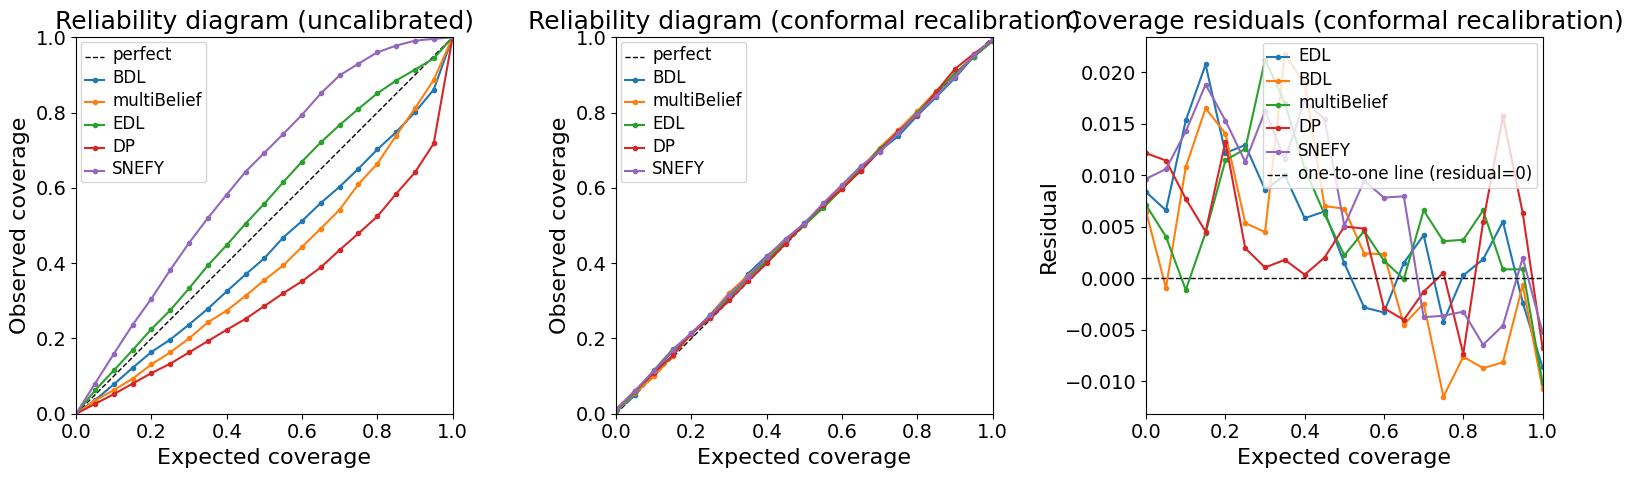

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ['EDL', 'BEDL', 'multiBelief', 'AA_BP', 'SNEFY_LDL']

cal_df = combine_metrics(models, datasets, ['kl_divergence', 'marginal_coverage_cal'], compact=True)
cal_df["model"] = cal_df["model"].replace('BEDL', 'BDL').replace('AA_BP', 'DP').replace('SNEFY_LDL', 'SNEFY')
raw_df = combine_metrics(models, datasets, ['kl_divergence', 'marginal_coverage'],     compact=True)
raw_df["model"] = raw_df["model"].replace('BEDL', 'BDL').replace('AA_BP', 'DP').replace('SNEFY_LDL', 'SNEFY')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plt.rcParams.update({'font.size': 14})

plot_marginal_coverage(raw_df, "marginal_coverage", axes[0], "Reliability diagram (uncalibrated)")
plot_marginal_coverage(cal_df, "marginal_coverage_cal", axes[1], "Reliability diagram (conformal recalibration)")
plot_conformal_residuals(models, datasets[0], axes[2])

# Increase font sizes across all subplots (titles, labels, ticks, legends)
for a in fig.axes:
    a.title.set_fontsize(18)
    a.xaxis.label.set_size(16)
    a.yaxis.label.set_size(16)
    a.tick_params(axis='both', labelsize=14)

    leg = a.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(12)

plt.tight_layout()
plt.show()
